# Importing Required Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the Dataset

In [ ]:
df = pd.read_csv('synthetic_fraud_dataset.csv')

# Exploratory Data Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
None

Missing values:
 transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0

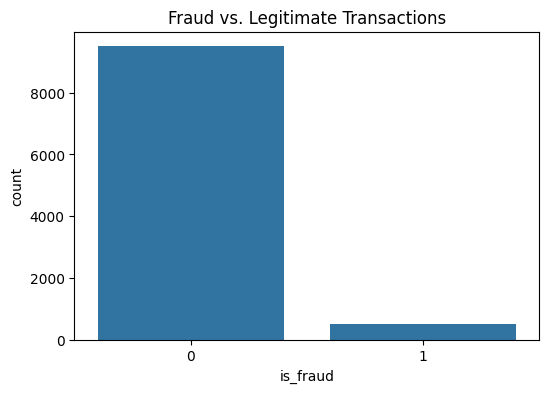

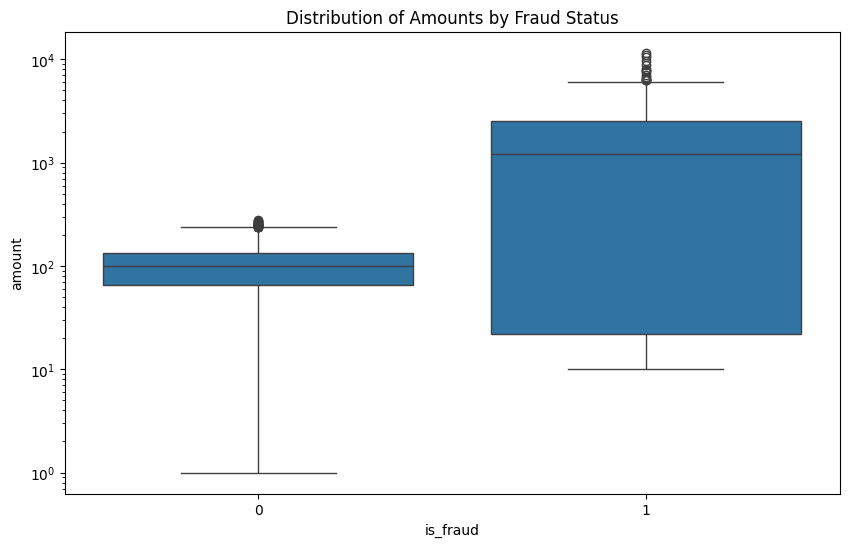

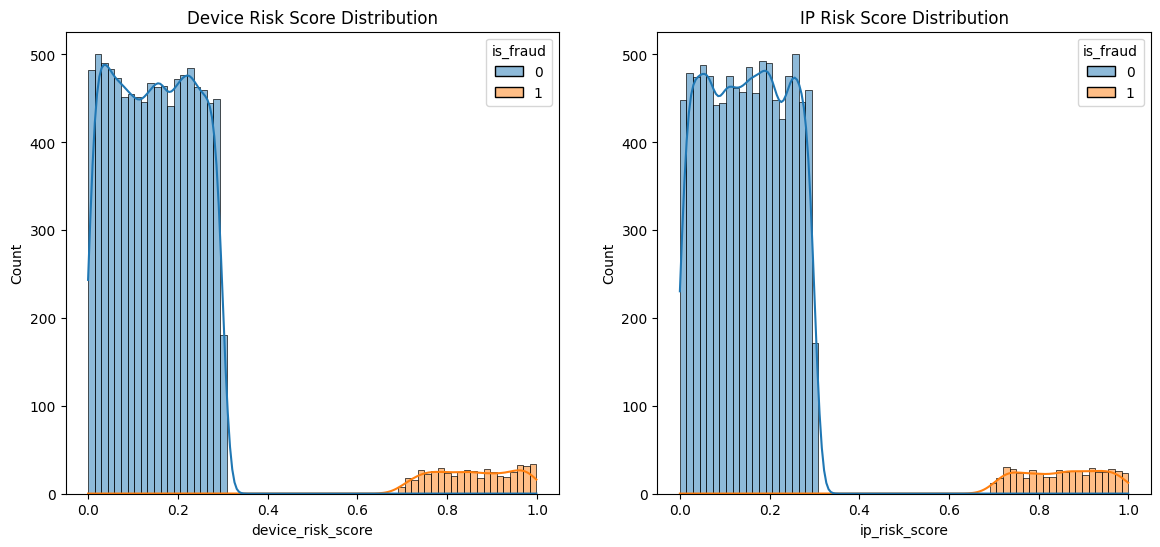

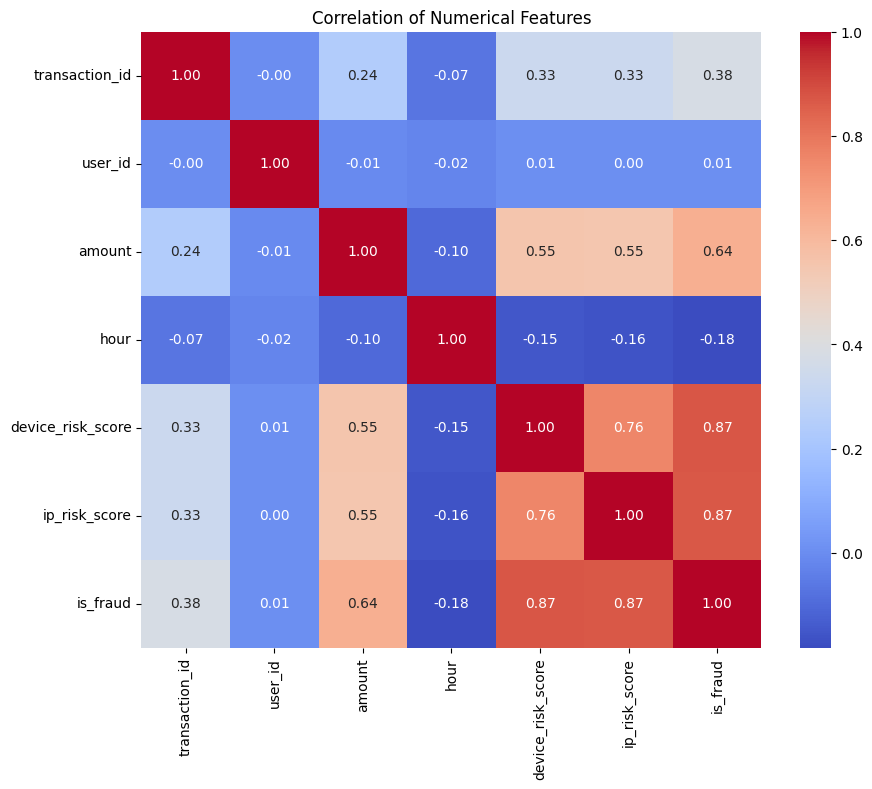

In [ ]:
# 1. Inspect data and missing values
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

# 2. Target Variable Analysis (Class Balance)
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title('Fraud vs. Legitimate Transactions')
plt.show()

# 3. Numerical Relationships (Amount vs Fraud)
plt.figure(figsize=(10,6))
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title('Distribution of Amounts by Fraud Status')
plt.yscale('log') # Log scale helps see small vs large values clearly
plt.show()

# 4. Risk Score Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df, x='device_risk_score', hue='is_fraud', kde=True, ax=axes[0])
axes[0].set_title('Device Risk Score Distribution')

sns.histplot(df, x='ip_risk_score', hue='is_fraud', kde=True, ax=axes[1])
axes[1].set_title('IP Risk Score Distribution')
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Numerical Features')
plt.show()

# Define Features and Labels

In [ ]:
X = df.drop(columns=['transaction_id', 'user_id', 'is_fraud'])
y = df['is_fraud']

# Data Preprocessing

In [ ]:
categorical_features = ['transaction_type', 'merchant_category', 'country']
numerical_features = ['amount', 'hour', 'device_risk_score', 'ip_risk_score']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])



# Apply preprocessing

In [ ]:
X_processed = preprocessor.fit_transform(X)


# Train Model

In [ ]:
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(X_processed)


IsolationForest(contamination=0.05, random_state=42)

# Predictions

In [ ]:
raw_predictions = model.predict(X_processed)
y_pred = [1 if x == -1 else 0 for x in raw_predictions]


# Evaluation

In [ ]:
print("\n--- Fraud Detection Performance ---")
print(classification_report(y, y_pred))


--- Fraud Detection Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9500
           1       1.00      1.00      1.00       500

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# Confusion Matrix

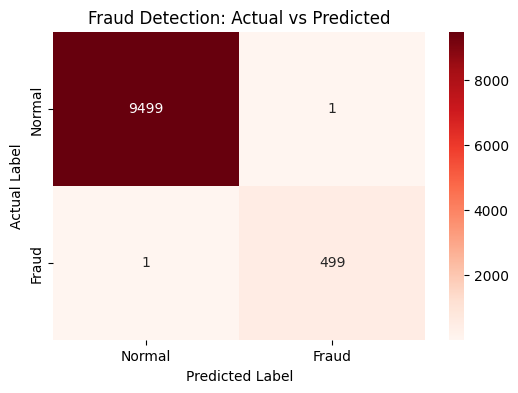

In [ ]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])

plt.title('Fraud Detection: Actual vs Predicted')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


#  Scatter Plot

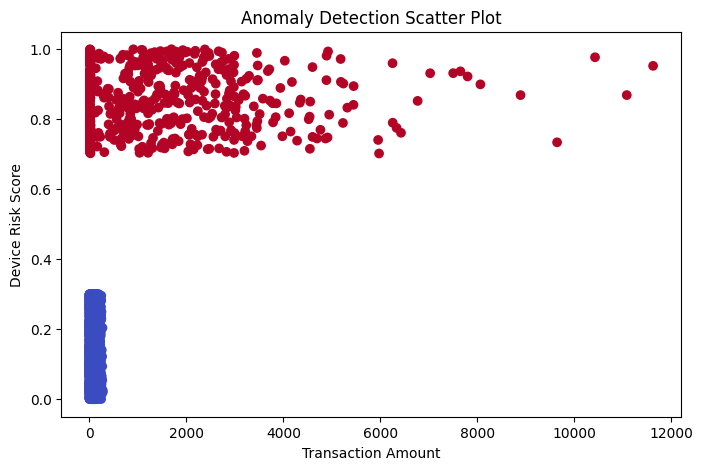

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df['amount'], df['device_risk_score'],
            c=y_pred, cmap='coolwarm')

plt.xlabel("Transaction Amount")
plt.ylabel("Device Risk Score")
plt.title("Anomaly Detection Scatter Plot")

plt.show()

# Accuracy

In [ ]:
accuracy = accuracy_score(y, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 99.98%
